This is an obsolete notebook for our model building. It is equivalent to our finalized notebook (02_model_building), except herein, we replaced rows with missing PercentResistant values with the corresponding region's mean PercentResistant value.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_squared_error
from sklearn.neighbors import KNeighborsRegressor

First, we import our merged dataset. Note the number of missing (NA) values that appear within each variable.

In [12]:
df = pd.read_csv('../data/raw/merged_with_antibiotics.csv')
# Replace "Empty" with NaN to treat them as missing values
df.replace("Empty", np.nan, inplace=True)

# Ensure data is numeric
df['PercentResistant'] = pd.to_numeric(df['PercentResistant'], errors='coerce')

# Fill missing PercentResistant values with the mean value for the corresponding region
df['PercentResistant'] = df.groupby('Region')['PercentResistant'].transform(
    lambda x: x.fillna(x.mean())
)
#df = pd.read_csv('../data/processed/dataset-updated.csv')
#print(df.info())
#df.head()
#print(df.isna().sum())

Here, we define our feature and target columns. Moreover, we plot each feature variable against our target variable (i.e., the percentage of E. Coli isolates that are resistant to Fluoroquinolones).

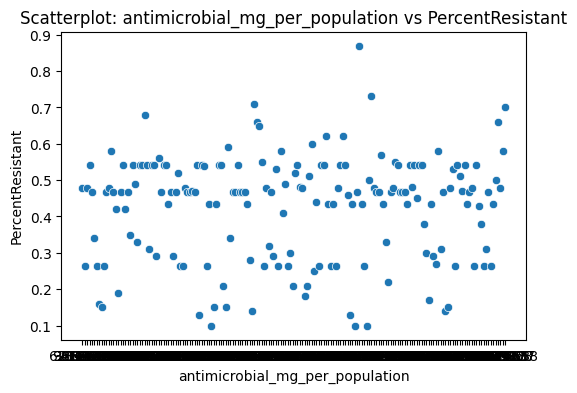

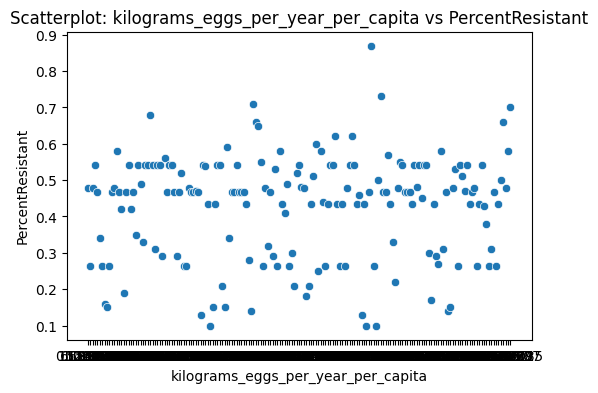

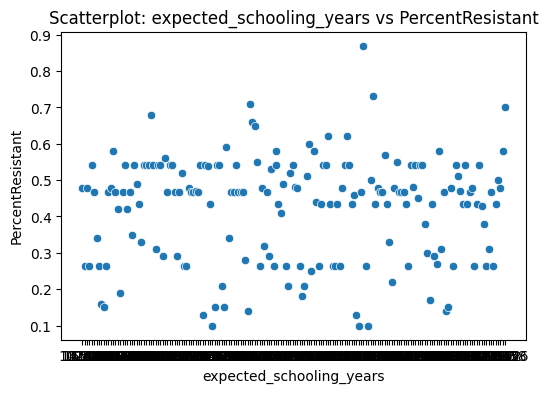

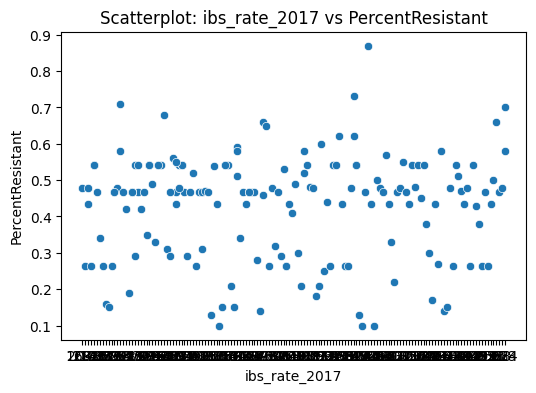

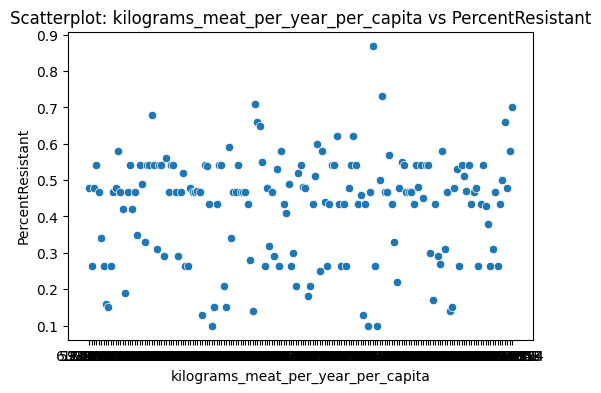

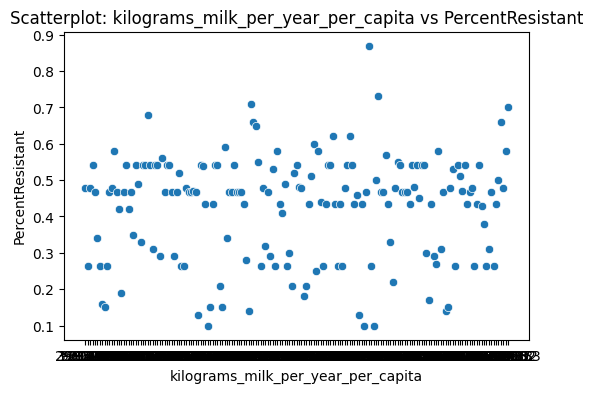

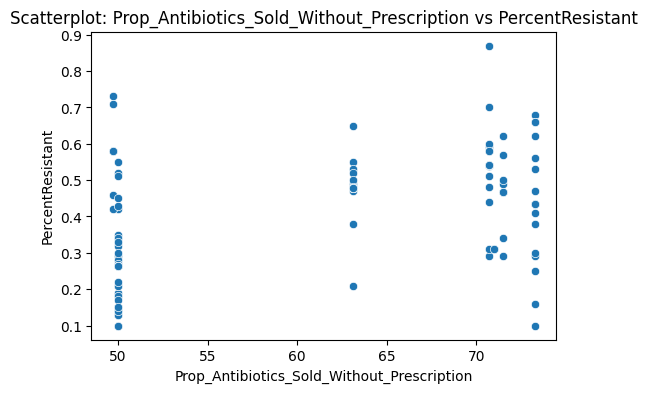

In [13]:
numeric_cols = ['antimicrobial_mg_per_population', 
                'kilograms_eggs_per_year_per_capita',
                'expected_schooling_years', 
                'ibs_rate_2017',
                'kilograms_meat_per_year_per_capita',
                'kilograms_milk_per_year_per_capita',
                'Prop_Antibiotics_Sold_Without_Prescription']
target = 'PercentResistant'
for col in numeric_cols:
    plt.figure(figsize=(6,4))
    sns.scatterplot(x=df[col], y=df[target])
    plt.title(f'Scatterplot: {col} vs {target}')
    plt.xlabel(col)
    plt.ylabel(target)
    plt.show()

In addition to the above visual bivariate relationships, we also compute the Pearson correlations between each possible feature-target pair. As a brief commentary, we observed the strongest correlation between per-capita milk consumption and rates of Irritable Bowel Syndrome (IBS), which makes sense given the prominent and established research on the gastrointestinal consequences of ingesting lactose. Additionally, the amount of antimicrobial use in livestock as well as the proportion of antibiotics sold in a given region positively influenced AR rates. 

In [14]:
# Filter out rows where all columns except 'Country' and 'Region' are equal to "Empty"
filtered_df = df.loc[~(df.iloc[:, 2:] == "Empty").all(axis=1)]

filtered_df.to_csv('filtered_df.csv', index=False)
# Remove rows with any cell equal to "Empty"
cleaned_df = filtered_df.loc[~(filtered_df == "Empty").any(axis=1)]

# Convert all columns except 'Country' and 'Region' to numeric
numeric_df = cleaned_df.iloc[:, 2:].apply(pd.to_numeric)

# Correlations
corrs = numeric_df.corr(method='spearman')
corrs

,antimicrobial_mg_per_population,kilograms_eggs_per_year_per_capita,expected_schooling_years,ibs_rate_2017,kilograms_meat_per_year_per_capita,kilograms_milk_per_year_per_capita,PercentResistant,Prop_Antibiotics_Sold_Without_Prescription
antimicrobial_mg_per_population,1.000000,0.164159,0.109074,0.037928,0.207037,-0.009151,-0.023184,0.249892
kilograms_eggs_per_year_per_capita,0.164159,1.000000,0.698030,0.614030,0.654927,0.632905,-0.484336,-0.115929
expected_schooling_years,0.109074,0.698030,1.000000,0.627811,0.702572,0.655638,-0.563791,-0.166243
ibs_rate_2017,0.037928,0.614030,0.627811,1.000000,0.477695,0.657158,-0.605204,-0.461063
kilograms_meat_per_year_per_capita,0.207037,0.654927,0.702572,0.477695,1.000000,0.554710,-0.535035,0.105760
kilograms_milk_per_year_per_capita,-0.009151,0.632905,0.655638,0.657158,0.554710,1.000000,-0.633576,-0.485396
PercentResistant,-0.023184,-0.484336,-0.563791,-0.605204,-0.535035,-0.633576,1.000000,0.180141
Prop_Antibiotics_Sold_Without_Prescription,0.249892,-0.115929,-0.166243,-0.461063,0.105760,-0.485396,0.180141,1.000000


Before conducting our model analyses, we must process and prep our dataset. 

In [20]:
numeric_transformer = Pipeline(steps=[ # First, preprocess the data
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])
preprocessor = ColumnTransformer( # This allows the data to all readable
    transformers=[
        ('num', numeric_transformer, numeric_cols)
    ])

In [21]:
X = df[numeric_cols]
# Handle missing values in features by filling with column mean
# Fill missing PercentResistant values with the mean value for the corresponding region
def fill_missing_values(df, column):
    # Convert column to numeric, coercing errors to NaN
    df[column] = pd.to_numeric(df[column], errors='coerce')
    # Fill missing values with the mean of the group
    df[column] = df.groupby('Region')[column].transform(
        lambda x: x.fillna(x.mean())
    )

for col in numeric_cols:
    fill_missing_values(df, col)

y = df[target]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f'Training samples: {X_train.shape[0]}')
print(f'Testing samples: {X_test.shape[0]}')


Training samples: 193
Testing samples: 49


In [25]:
# Linear regression model
linreg_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('regressor', LinearRegression())
])
# Fill missing values in y_train with the mean of y_train
y_train = y_train.fillna(y_train.mean())

linreg_pipeline.fit(X_train, y_train)

print("\nLinear Regression Results:")
print("Training R^2 Score:", linreg_pipeline.score(X_train, y_train))

# Predict on the test set
y_pred_linreg = linreg_pipeline.predict(X_test)

print("Test R^2 Score:", r2_score(y_test, y_pred_linreg))
mse = mean_squared_error(y_test, y_pred_linreg)
rmse = np.sqrt(mse)
print("MSE:", mse)
print("RMSE:", rmse)


Linear Regression Results:
Training R^2 Score: 0.5701215583213712
Test R^2 Score: 0.6177439077410514
MSE: 0.006285682419851257
RMSE: 0.079282295752906


In [26]:
# First part of random forest model (decision tree model)
rf_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('regressor', RandomForestRegressor(n_estimators=100, random_state=42))
])

rf_pipeline.fit(X_train, y_train)

y_pred_rf = rf_pipeline.predict(X_test)

print("\nRandom Forest Results:")
print("Training R^2 Score:", rf_pipeline.score(X_train, y_train))
print("Test R^2 Score:", r2_score(y_test, y_pred_rf))
mse_rf = mean_squared_error(y_test, y_pred_rf)
rmse_rf = np.sqrt(mse_rf)
print("MSE:", mse_rf)
print("RMSE:", rmse_rf)


Random Forest Results:
Training R^2 Score: 0.9397721917403028
Test R^2 Score: 0.6828241978578364
MSE: 0.005215525413200387
RMSE: 0.07221859464985722


In [27]:
# KNN model 
knn_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('regressor', KNeighborsRegressor(n_neighbors=5))  # you can try k=3, 5, 7
])

knn_pipeline.fit(X_train, y_train)

y_pred_knn = knn_pipeline.predict(X_test)

print("\nK-Nearest Neighbors Regression Results:")
print("R^2 Score:", r2_score(y_test, y_pred_knn)) #testing
mse_knn = mean_squared_error(y_test, y_pred_knn)
rmse_knn = np.sqrt(mse_knn)
y_train_pred_knn = knn_pipeline.predict(X_train)
print("Training R²:", r2_score(y_train, y_train_pred_knn))
print("MSE:", mse_knn)
print("RMSE:", rmse_knn)


K-Nearest Neighbors Regression Results:
R^2 Score: 0.6871407501255498
Training R²: 0.6461973894176218
MSE: 0.00514454557205987
RMSE: 0.07172548760419736


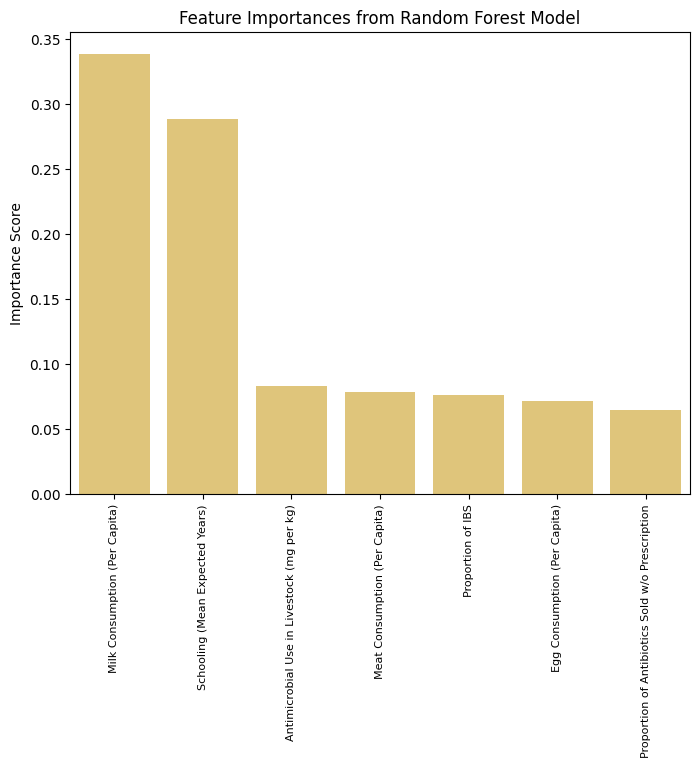

In [28]:
rf_model = rf_pipeline.named_steps['regressor']
feature_importances = pd.Series(rf_model.feature_importances_, index=numeric_cols).sort_values(ascending=False)

plt.figure(figsize=(8,6))
feature_importances.plot(kind='bar')
plt.title('Feature Importances from Random Forest Model')
plt.ylabel('Importance Score')
plt.xticks(ticks=range(len(feature_importances)), labels=['Milk Consumption (Per Capita)', 'Schooling (Mean Expected Years)', 'Antimicrobial Use in Livestock (mg per kg)', 'Meat Consumption (Per Capita)', 'Proportion of IBS', 'Egg Consumption (Per Capita)', 'Proportion of Antibiotics Sold w/o Prescription'], fontsize=8, rotation=90)
plt.bar(feature_importances.index, feature_importances.values, color='#DFC57B')
plt.show()

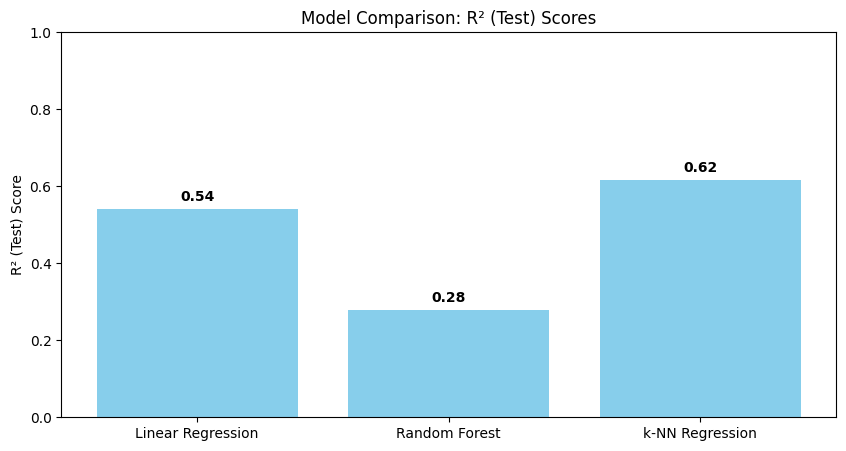

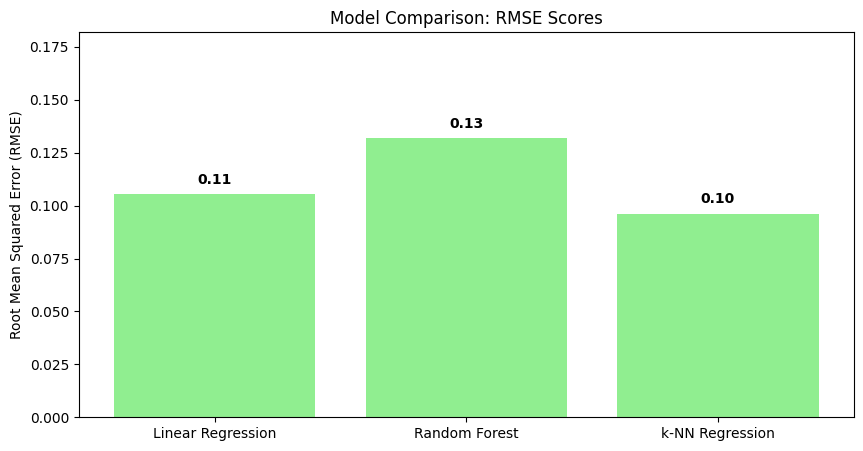

In [29]:
# Comparison plot of all our models
import matplotlib.pyplot as plt

model_names = ['Linear Regression', 'Random Forest', 'k-NN Regression']
r2_scores = [0.5416, 0.2798, 0.6171]
rmse_scores = [0.1053, 0.1319, 0.0962]

#  plot r^2 scores
plt.figure(figsize=(10, 5))
plt.bar(model_names, r2_scores, color='skyblue')
plt.title('Model Comparison: R² (Test) Scores')
plt.ylabel('R² (Test) Score')
plt.ylim(0, 1)
for i, v in enumerate(r2_scores):
    plt.text(i, v + 0.02, f"{v:.2f}", ha='center', fontweight='bold')
plt.show()

#Plot root MSE Scores 
plt.figure(figsize=(10, 5))
plt.bar(model_names, rmse_scores, color='lightgreen')
plt.title('Model Comparison: RMSE Scores')
plt.ylabel('Root Mean Squared Error (RMSE)')
plt.ylim(0, max(rmse_scores) + 0.05)
for i, v in enumerate(rmse_scores):
    plt.text(i, v + 0.005, f"{v:.2f}", ha='center', fontweight='bold')
plt.show()


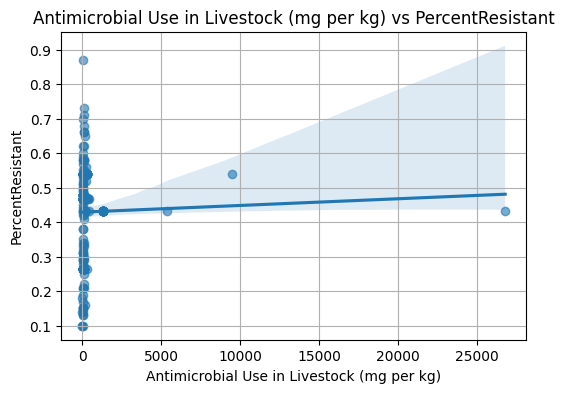

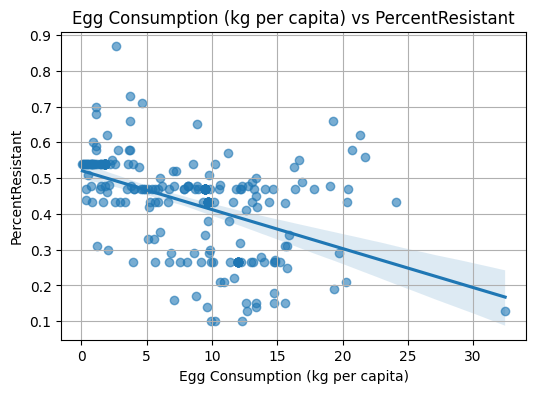

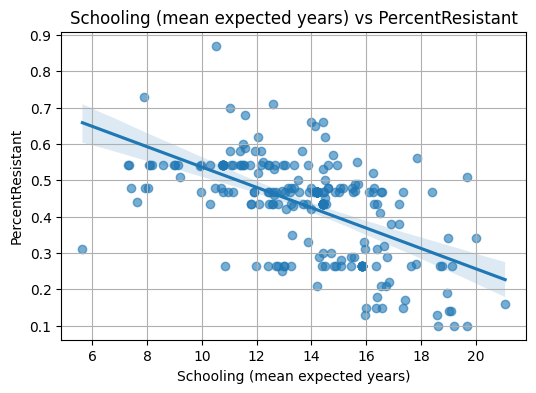

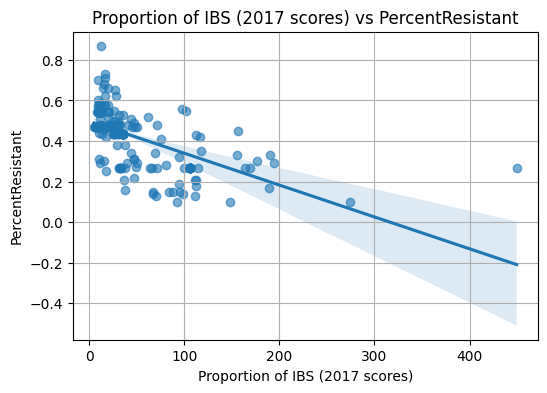

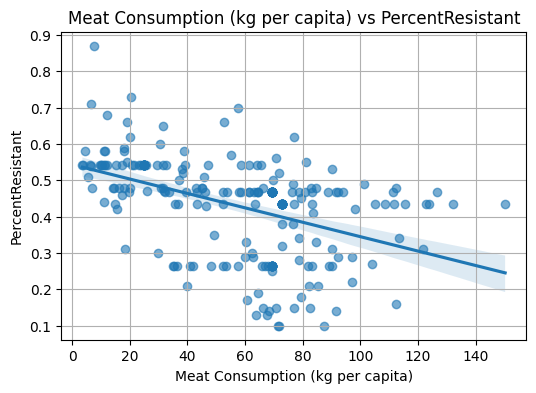

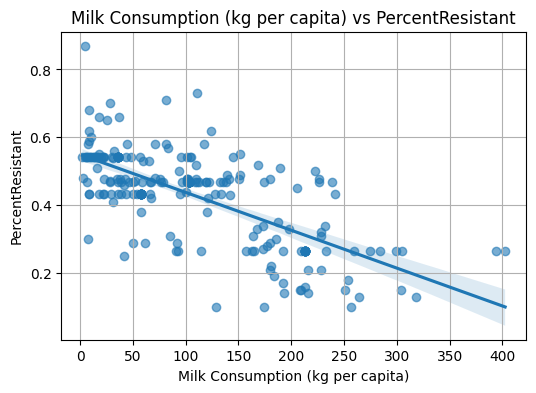

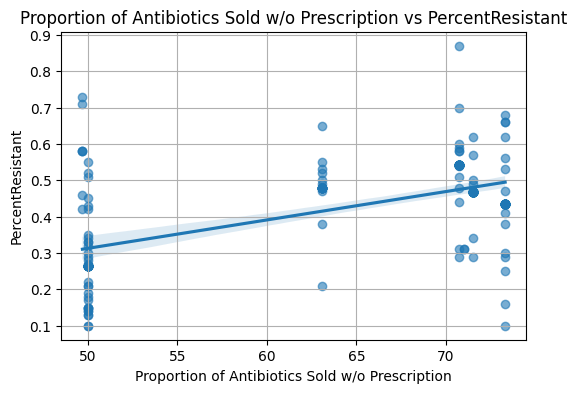

In [30]:
# Regression impact
import seaborn as sns
import matplotlib.pyplot as plt

numeric_cols = ['antimicrobial_mg_per_population', 
                'kilograms_eggs_per_year_per_capita',
                'expected_schooling_years', 
                'ibs_rate_2017',
                'kilograms_meat_per_year_per_capita',
                'kilograms_milk_per_year_per_capita',
                'Prop_Antibiotics_Sold_Without_Prescription']

target = 'PercentResistant'

# Custom labels
custom_labels = {
    'antimicrobial_mg_per_population': 'Antimicrobial Use in Livestock (mg per kg)',
    'kilograms_eggs_per_year_per_capita': 'Egg Consumption (kg per capita)',
    'expected_schooling_years': 'Schooling (mean expected years)',
    'ibs_rate_2017': 'Proportion of IBS (2017 scores)',
    'kilograms_meat_per_year_per_capita': 'Meat Consumption (kg per capita)',
    'kilograms_milk_per_year_per_capita': 'Milk Consumption (kg per capita)',
    'Prop_Antibiotics_Sold_Without_Prescription': 'Proportion of Antibiotics Sold w/o Prescription'
}
# For each predictor, we plot a scatterplot with the regression line
for col in numeric_cols:
    plt.figure(figsize=(6,4))
    sns.regplot(x=df[col], y=df[target], scatter_kws={'alpha':0.6})
    plt.title(f'{custom_labels[col]} vs {target}')
    plt.xlabel(custom_labels[col])
    plt.ylabel(f'Percent of Resistant Isolates')
    plt.ylabel(target)
    plt.grid(True)
    plt.show()

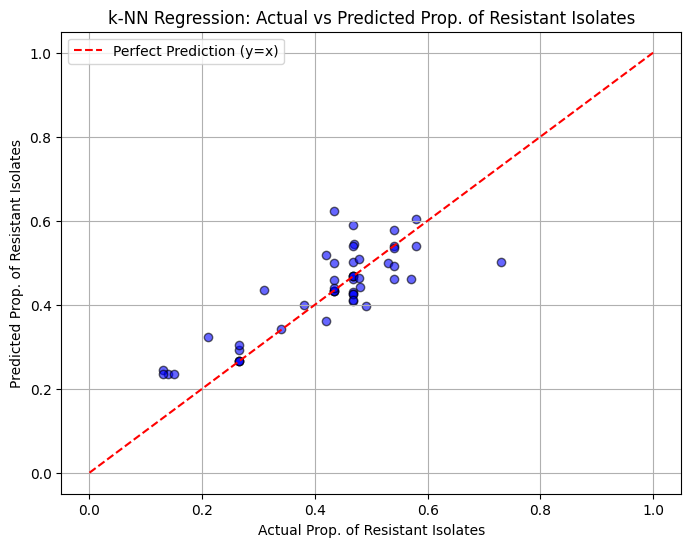

In [31]:
import matplotlib.pyplot as plt
import numpy as np

# plot Actual vs Predicted for k-NN model
plt.figure(figsize=(8,6))
plt.scatter(y_test, y_pred_knn, color='blue', alpha=0.6, edgecolor='k')
plt.plot([0, 1], [0, 1], '--r', label='Perfect Prediction (y=x)')
plt.xlabel('Actual Prop. of Resistant Isolates')
plt.ylabel('Predicted Prop. of Resistant Isolates')
plt.title('k-NN Regression: Actual vs Predicted Prop. of Resistant Isolates')
plt.legend()
plt.grid(True)
plt.show()

# Points that are close to the red dashed line indicate a more accurate prediction by the k-NN model
# Scattered points indicate more significant errors.
